# 02 - Limpieza y Transformacion de Datos
Conversion de columnas de fecha y preparacion del dataset para analisis temporal.

In [1]:
import pandas as pd

df = pd.read_csv('../data/Sample_Superstore.csv', encoding='ISO-8859-1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [2]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y', errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%m/%d/%Y', errors='coerce')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

In [3]:
df[['Order Date', 'Ship Date']].isnull().sum()

Order Date    0
Ship Date     0
dtype: int64

In [4]:
df['Dias de envio'] = (df['Ship Date'] - df['Order Date']).dt.days
df[['Order Date', 'Ship Date', 'Dias de envio']].head()

,Order Date,Ship Date,Dias de envio
0,2016-11-08,2016-11-11,3
1,2016-11-08,2016-11-11,3
2,2016-06-12,2016-06-16,4
3,2015-10-11,2015-10-18,7
4,2015-10-11,2015-10-18,7


In [5]:
print('Dias de envio promedio:', df['Dias de envio'].mean().round(2))
print('Dias de envio maximo:', df['Dias de envio'].max())
print('Dias de envio minimo:', df['Dias de envio'].min())

Dias de envio promedio: 3.96
Dias de envio maximo: 7
Dias de envio minimo: 0


In [6]:
dias_por_modo = df.groupby('Ship Mode')['Dias de envio'].mean().sort_values()
print(dias_por_modo)

Ship Mode
Same Day          0.044199
First Class       2.182705
Second Class      3.238046
Standard Class    5.006535
Name: Dias de envio, dtype: float64


## Hallazgo: Tiempo de envio consistente con la modalidad contratada

El tiempo de envio promedio es de 3.96 dias, con un rango de 0 a 7 dias. 
El tiempo por modalidad de envio es coherente con lo esperado:

- Same Day: 0.04 dias
- First Class: 2.18 dias
- Second Class: 3.24 dias
- Standard Class: 5.01 dias

No se detectaron valores negativos (que indicarian un envio registrado antes 
del pedido), lo que sugiere buena calidad de datos en estas columnas.

# 1. Análisis de clientes individuales
## 1.1 ¿Quiénes son los clientes que más compran (por ventas totales)?

In [8]:
top_clientes_ventas = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)
print(top_clientes_ventas)

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64


## 1.2 ¿Quiénes generan más ganancia?

In [9]:
top_clientes_ganancia = df.groupby('Customer Name')['Profit'].sum().sort_values(ascending=False).head(10)
print(top_clientes_ganancia)

Customer Name
Tamara Chand            8981.3239
Raymond Buch            6976.0959
Sanjit Chand            5757.4119
Hunter Lopez            5622.4292
Adrian Barton           5444.8055
Tom Ashbrook            4703.7883
Christopher Martinez    3899.8904
Keith Dawkins           3038.6254
Andy Reiter             2884.6208
Daniel Raglin           2869.0760
Name: Profit, dtype: float64


## 1.3 ¿Hay clientes que compran mucho pero generan pérdida neta?

In [10]:
resumen_clientes = df.groupby('Customer Name').agg(
    ventas_totales=('Sales', 'sum'),
    ganancia_total=('Profit', 'sum')
).sort_values('ventas_totales', ascending=False)

# Filtra: clientes en el top 20 de ventas, pero con ganancia negativa
clientes_problematicos = resumen_clientes.head(20)[resumen_clientes.head(20)['ganancia_total'] < 0]
print(clientes_problematicos)

               ventas_totales  ganancia_total
Customer Name                                
Sean Miller          25043.05      -1980.7393
Becky Martin         11789.63      -1659.9581


In [11]:
compras_sean = df[df['Customer Name'] == 'Sean Miller']
print(compras_sean[['Category', 'Sub-Category', 'Region', 'Discount', 'Profit']])

             Category Sub-Category   Region  Discount     Profit
2266  Office Supplies        Paper    South       0.2     2.6892
2573        Furniture  Furnishings  Central       0.0    31.5870
2696       Technology     Machines    South       0.5   -16.4260
2697       Technology     Machines    South       0.5 -1811.0784
2698  Office Supplies        Paper    South       0.2     7.4816
2699  Office Supplies          Art    South       0.2     1.0020
2700        Furniture  Furnishings    South       0.2     8.0766
2701  Office Supplies    Fasteners    South       0.2     5.9175
2702        Furniture  Furnishings    South       0.2    15.2940
7853  Office Supplies        Paper     West       0.0     4.8804
9187  Office Supplies     Supplies     East       0.2    -0.6976
9188       Technology  Accessories     East       0.2     3.8024
9189  Office Supplies      Storage     East       0.2  -165.7680
9190  Office Supplies      Binders     East       0.7   -82.9900
9191  Office Supplies    

### Hallazgo: El caso de Sean Miller es una anomalia aislada, no un patron sistemico

Se esperaba que la perdida de Sean Miller (el cliente #1 en ventas, con -$1,980 
en ganancia neta) estuviera relacionada con los patrones ya identificados 
(Furniture/Tables o region Central). Sin embargo, el detalle de sus 15 
transacciones revela algo distinto:

Una sola transaccion de Technology/Machines en la region South, con 50% de 
descuento, genero una perdida de -$1,811 -- que por si sola explica casi toda 
la perdida neta del cliente.

Esto sugiere que el caso de Sean Miller no es un ejemplo de los patrones 
sistemicos de Furniture o Central, sino una transaccion individual atipica 
(posiblemente una venta de equipo costoso con descuento excesivo) que amerita 
revision puntual, no un ajuste de politica general.

## ¿Hay más transacciones como esta?

In [12]:
transacciones_extremas = df.sort_values('Profit').head(10)
print(transacciones_extremas[['Customer Name', 'Category', 'Sub-Category', 'Discount', 'Profit']])

         Customer Name         Category Sub-Category  Discount     Profit
7772     Cindy Stewart       Technology     Machines       0.7 -6599.9780
683     Grant Thornton       Technology     Machines       0.5 -3839.9904
9774       Luke Foster  Office Supplies      Binders       0.8 -3701.8928
3011    Sharelle Roach       Technology     Machines       0.7 -3399.9800
4991     Henry Goldwyn  Office Supplies      Binders       0.8 -2929.4845
3151  Natalie Fritzler       Technology     Machines       0.7 -2639.9912
5310       Nathan Cano  Office Supplies      Binders       0.8 -2287.7820
9639       Joseph Holt        Furniture       Tables       0.4 -1862.3124
1199  Zuschuss Carroll  Office Supplies      Binders       0.8 -1850.9464
2697       Sean Miller       Technology     Machines       0.5 -1811.0784


## Hallazgo principal: Los descuentos extremos (>40%) son la causa raiz de las 
## perdidas mas graves, independientemente de la categoria

Al analizar las 10 transacciones con mayor perdida individual del dataset 
completo, se encuentra un patron mas fuerte que cualquier categoria especifica:

- Las 10 peores transacciones tienen descuentos entre 40% y 80%
- 5 de 10 son de la sub-categoria Machines (Technology)
- 4 de 10 son de la sub-categoria Binders (Office Supplies)
- Solo 1 de 10 es de Tables (Furniture), la sub-categoria previamente 
  identificada como problematica

Esto revela que el verdadero factor de riesgo no es la categoria de producto 
en si (Technology y Office Supplies son, en promedio, las categorias MAS 
rentables del negocio), sino la aplicacion de descuentos extremos (>40%) en 
productos de alto valor unitario como maquinas y encuadernadoras industriales. 
Se recomienda establecer un limite maximo de descuento (por ejemplo, 30-40%) 
para estas sub-categorias especificas, en lugar de un ajuste general por 
categoria.

In [13]:
correlacion = df['Discount'].corr(df['Profit'])
print(f'Correlacion entre Discount y Profit: {correlacion:.3f}')

Correlacion entre Discount y Profit: -0.219


In [14]:
for umbral in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
    perdida_promedio = df[df['Discount'] >= umbral]['Profit'].mean()
    print(f'Descuento >= {umbral:.0%}: ganancia promedio = ${perdida_promedio:.2f}')

Descuento >= 10%: ganancia promedio = $-6.66
Descuento >= 20%: ganancia promedio = $-8.92
Descuento >= 30%: ganancia promedio = $-97.18
Descuento >= 40%: ganancia promedio = $-107.65
Descuento >= 50%: ganancia promedio = $-105.28
Descuento >= 60%: ganancia promedio = $-89.44
Descuento >= 70%: ganancia promedio = $-98.35


## Hallazgo: El 30% de descuento es el punto de quiebre critico

La correlacion entre Discount y Profit es de -0.219 (negativa, moderada), 
confirmando que el descuento influye en la rentabilidad pero no es el unico 
factor determinante.

Sin embargo, al analizar la ganancia promedio por umbral de descuento, se 
identifica un punto de quiebre claro entre 20% y 30%:

- Descuento >= 20%: ganancia promedio de -$8.92 (perdida leve)
- Descuento >= 30%: ganancia promedio de -$97.18 (perdida severa, 11x peor)

Esto sugiere que 30% podria ser un limite practico de politica de descuentos: 
por debajo de este umbral, el impacto en rentabilidad es manejable; a partir 
de el, las perdidas se vuelven sistematicamente severas. Se recomienda que 
cualquier descuento superior al 30% requiera aprobacion adicional o 
justificacion de negocio.

# 2. Estacionalidad temporal
## 2.1 ¿Hay meses o trimestres con más ventas?

In [15]:
df['Mes'] = df['Order Date'].dt.month
df['Año'] = df['Order Date'].dt.year

df[['Order Date', 'Mes', 'Año']].head()

,Order Date,Mes,Año
0,2016-11-08,11,2016
1,2016-11-08,11,2016
2,2016-06-12,6,2016
3,2015-10-11,10,2015
4,2015-10-11,10,2015


In [16]:
ventas_por_mes = df.groupby('Mes')['Sales'].sum()
print(ventas_por_mes)

Mes
1      94924.8356
2      59751.2514
3     205005.4888
4     137762.1286
5     155028.8117
6     152718.6793
7     147238.0970
8     159044.0630
9     307649.9457
10    200322.9847
11    352461.0710
12    325293.5035
Name: Sales, dtype: float64


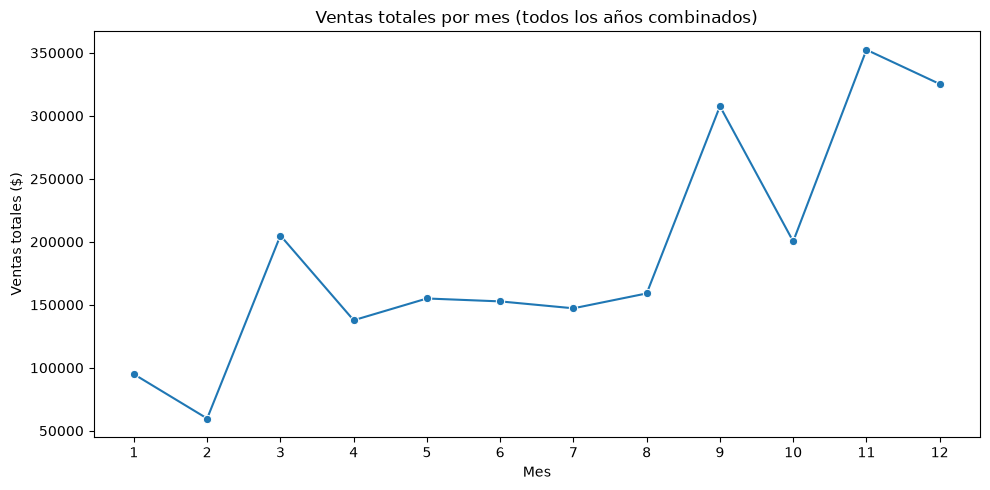

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.lineplot(x=ventas_por_mes.index, y=ventas_por_mes.values, marker='o')
plt.title('Ventas totales por mes (todos los años combinados)')
plt.xlabel('Mes')
plt.ylabel('Ventas totales ($)')
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

## 2.2 ¿Ha habido una tendencia de crecimiento año con año?

In [18]:
ventas_por_año = df.groupby('Año')['Sales'].sum()
print(ventas_por_año)

Año
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64


### Hallazgo: Estacionalidad marcada, con pico en noviembre-diciembre

A diferencia de un patron aleatorio, las ventas muestran estacionalidad clara:

- Meses mas debiles: Febrero (~$60K) y Enero (~$95K)
- Meses mas fuertes: Noviembre (~$352K), Diciembre (~$325K) y Septiembre (~$308K)

Noviembre vende casi 6 veces mas que Febrero, un patron consistente con 
eventos de compra de fin de año (Black Friday, Cyber Monday, temporada 
navidena) y posiblemente compras de regreso a oficina en septiembre.

### Hallazgo: Crecimiento sostenido del negocio (2015-2017)

Las ventas anuales crecieron de $470,532 en 2015 a $733,215 en 2017 (+56% en 
dos años), con una ligera caida entre 2014 y 2015. Esto indica un negocio en 
expansion, y sugiere que el inventario y personal deberian planificarse con 
mayor capacidad para los meses de alta demanda (septiembre, noviembre, 
diciembre).

In [19]:
ganancia_por_mes = df.groupby('Mes')['Profit'].sum()
print(ganancia_por_mes)

Mes
1      9134.4461
2     10294.6107
3     28594.6872
4     11587.4363
5     22411.3078
6     21285.7954
7     13832.6648
8     21776.9384
9     36857.4753
10    31784.0413
11    35468.4265
12    43369.1919
Name: Profit, dtype: float64


In [20]:
margen_por_mes = (ganancia_por_mes / ventas_por_mes) * 100
print(margen_por_mes.round(2))

Mes
1      9.62
2     17.23
3     13.95
4      8.41
5     14.46
6     13.94
7      9.39
8     13.69
9     11.98
10    15.87
11    10.06
12    13.33
dtype: float64


### Hallazgo: Noviembre tiene el mayor volumen de ventas pero uno de los margenes mas bajos del año

Al calcular el margen de ganancia (ganancia/ventas) por mes, se confirma que 
el pico de ventas de noviembre no se traduce en la misma eficiencia de 
rentabilidad:

- Febrero: menor volumen de ventas del año, pero el MEJOR margen (17.23%)
- Noviembre: mayor volumen de ventas del año, pero margen de solo 10.06%

Este patron es consistente con el hallazgo previo sobre descuentos: es muy 
probable que las promociones de temporada (Black Friday, Cyber Monday) 
impulsen el volumen de ventas de noviembre a costa de un margen mas bajo. 
Se recomienda evaluar si el nivel de descuento aplicado durante esta temporada 
esta bien calibrado, o si un ajuste moderado podria mejorar la rentabilidad 
sin sacrificar significativamente el volumen.

# 3. Productos específicos
## 3.1 ¿Cuáles son los 10 productos individuales (Product Name) que más pérdida generan?

## 3.2 ¿Hay productos que se venden mucho pero individualmente son un problema?

# 4. Relación Quantity vs Discount vs Profit
## 4.1 ¿Los pedidos de mayor cantidad reciben más descuento?

## 4.2 ¿Existe correlación entre Quantity y Profit?

# 5. Análisis geográfico más fino
## 5.1 ¿Hay estados específicos con problemas de rentabilidad, más allá de la región general?